In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#Dataset: https://www.kaggle.com/datasets/danielcorredera/student-mat-csv?select=student-mat.csv


In [6]:
# Load dataset
url = "/content/student-mat.csv"
df = pd.read_csv(url, sep=';')
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [7]:
# Feature and Target
X = df[['studytime']]
y = df['G3']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Parameters
print("\nIntercept :", model.intercept_)
print("Coefficient :", model.coef_[0])

# Prediction
y_pred = model.predict(X_test)


Intercept : 8.772737067417506
Coefficient : 0.7586013704730578


In [11]:
# Performance Metrics
print("\nMAE :", mean_absolute_error(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("R2 Score :", r2_score(y_test, y_pred))


MAE : 3.678962967623515
MSE : 21.492916098598933
RMSE : 4.636045308083058
R2 Score : -0.048176861902259116


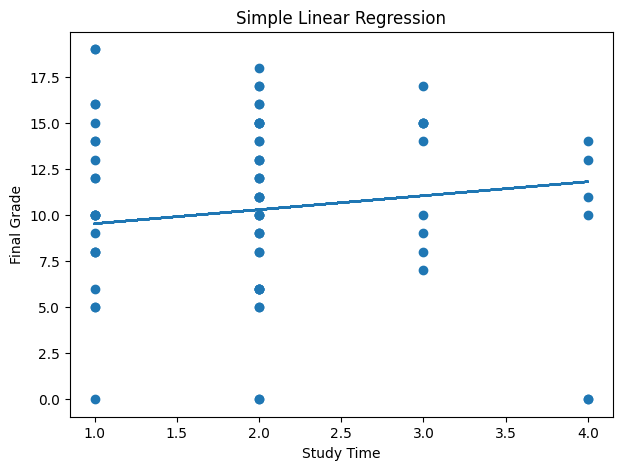

In [12]:
# Regression Line
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Simple Linear Regression")
plt.show()

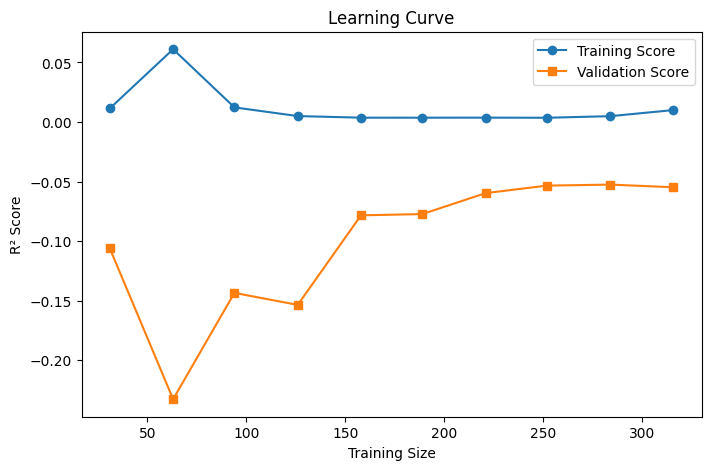

In [10]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1,1.0,10),
    scoring='r2'
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Score')
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.show()